# Retail Sales Analysis using SQL, Python, and Tableau


## Project Goal

The goal of this project is to analyse retail sales performance and answer key business questions such as:

- How are sales and profit performing over time?
- Which products generate the most revenue?
- Which regions perform best?
- How do discount and shipping patterns affect performance?
- What important business insights can decision-makers take from the data?


In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [17]:

df = pd.read_csv(r"D:\My portfolio\my first sql to tableau project\SQL cleaning , adding and analysing\retail_project_python\sales_data_clean.csv.csv")
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country_region,city,...,sub_category,product_name,sales,quantity,discount,profit,revenue_per_item,profit_margin,order_month,order_year
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.45,2,0.2,5.5512,8.225000,0.337459,2023-01-01,2023
1,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Storage,SAFCO Boltless Steel Shelving,272.74,3,0.2,-64.7748,90.913333,-0.237497,2023-01-01,2023
2,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Binders,GBC Standard Plastic Binding Systems Combs,3.54,2,0.8,-5.4870,1.770000,-1.550000,2023-01-01,2023
3,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Labels,Avery 508,11.78,3,0.2,4.2717,3.926667,0.362623,2023-01-01,2023
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.54,3,0.2,4.8840,6.513333,0.249949,2023-01-01,2023


In [19]:

df.shape



(7258, 25)

In [20]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country_region', 'city',
       'state_province', 'postal_code', 'region', 'product_id', 'category',
       'sub_category', 'product_name', 'sales', 'quantity', 'discount',
       'profit', 'revenue_per_item', 'profit_margin', 'order_month',
       'order_year'],
      dtype='object')

In [21]:

df.columns = df.columns.str.strip().str.lower()
df.columns


Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country_region', 'city',
       'state_province', 'postal_code', 'region', 'product_id', 'category',
       'sub_category', 'product_name', 'sales', 'quantity', 'discount',
       'profit', 'revenue_per_item', 'profit_margin', 'order_month',
       'order_year'],
      dtype='object')

In [22]:

df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["ship_date"] = pd.to_datetime(df["ship_date"], errors="coerce")
df["order_month"] = pd.to_datetime(df["order_month"], errors="coerce")


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7258 entries, 0 to 7257
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   row_id            7258 non-null   int64         
 1   order_id          7258 non-null   object        
 2   order_date        7258 non-null   datetime64[ns]
 3   ship_date         7258 non-null   datetime64[ns]
 4   ship_mode         7258 non-null   object        
 5   customer_id       7258 non-null   object        
 6   customer_name     7258 non-null   object        
 7   segment           7258 non-null   object        
 8   country_region    7258 non-null   object        
 9   city              7258 non-null   object        
 10  state_province    7258 non-null   object        
 11  postal_code       7258 non-null   object        
 12  region            7258 non-null   object        
 13  product_id        7258 non-null   object        
 14  category          7258 n

In [24]:
df.describe()

,row_id,order_date,ship_date,sales,quantity,discount,profit,revenue_per_item,profit_margin,order_month,order_year
count,7258.000000,7258,7258,7258.000000,7258.000000,7258.000000,7258.000000,7258.000000,7258.000000,7258,7258.000000
mean,3629.516533,2024-10-12 18:26:05.389914368,2024-10-16 18:06:14.979332864,232.441976,3.798016,0.155131,29.784753,61.212873,0.123715,2024-09-28 07:08:56.676770560,2024.202397
min,1.000000,2023-01-03 00:00:00,2023-01-07 00:00:00,0.560000,1.000000,0.000000,-6599.978000,0.335000,-2.749962,2023-01-01 00:00:00,2023.000000
25%,1815.250000,2023-12-06 06:00:00,2023-12-10 06:00:00,17.285000,2.000000,0.000000,1.764000,5.448929,0.074998,2023-12-01 00:00:00,2023.000000
50%,3629.500000,2024-11-10 00:00:00,2024-11-14 00:00:00,54.215000,3.000000,0.200000,8.803200,16.231667,0.270000,2024-11-01 00:00:00,2024.000000
75%,5443.750000,2025-08-23 00:00:00,2025-08-28 00:00:00,210.945000,5.000000,0.200000,29.976750,63.980000,0.362516,2025-08-01 00:00:00,2025.000000
max,7274.000000,2026-03-25 00:00:00,2026-03-26 00:00:00,22638.480000,14.000000,0.800000,8399.976000,3773.080000,0.500000,2026-03-01 00:00:00,2026.000000
std,2095.377095,NaN,NaN,647.976158,2.223179,0.206195,238.691159,142.737880,0.460162,NaN,0.921299


In [25]:
df[["order_date", "sales", "quantity", "product_id", "customer_id", "region"]].isna().sum()

order_date     0
sales          0
quantity       0
product_id     0
customer_id    0
region         0
dtype: int64

In [26]:
df["row_id"].duplicated().sum()

np.int64(0)

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
(df["ship_date"] < df["order_date"]).sum()

np.int64(0)

In [29]:

print("Sales <= 0:", (df["sales"] <= 0).sum())
print("Quantity <= 0:", (df["quantity"] <= 0).sum())
print("Discount outside 0 to 1:", ((df["discount"] < 0) | (df["discount"] > 1)).sum())


Sales <= 0: 0
Quantity <= 0: 0
Discount outside 0 to 1: 0


In [30]:

quality_summary = pd.DataFrame({
    "issue": [
        "missing_order_date",
        "missing_sales",
        "missing_quantity",
        "duplicate_row_id",
        "duplicate_full_rows",
        "ship_date_before_order_date",
        "sales_less_than_or_equal_to_zero",
        "quantity_less_than_or_equal_to_zero",
        "discount_outside_0_to_1"
    ],
    "count": [
        df["order_date"].isna().sum(),
        df["sales"].isna().sum(),
        df["quantity"].isna().sum(),
        df["row_id"].duplicated().sum(),
        df.duplicated().sum(),
        (df["ship_date"] < df["order_date"]).sum(),
        (df["sales"] <= 0).sum(),
        (df["quantity"] <= 0).sum(),
        ((df["discount"] < 0) | (df["discount"] > 1)).sum()
    ]
})

quality_summary


,issue,count
0,missing_order_date,0
1,missing_sales,0
2,missing_quantity,0
3,duplicate_row_id,0
4,duplicate_full_rows,0
5,ship_date_before_order_date,0
6,sales_less_than_or_equal_to_zero,0
7,quantity_less_than_or_equal_to_zero,0
8,discount_outside_0_to_1,0


In [31]:

weird_product_names = df[df["product_name"].astype(str).str.contains("Ã|Â", regex=True, na=False)]
weird_customer_names = df[df["customer_name"].astype(str).str.contains("Ã|Â", regex=True, na=False)]

print("Weird product names:", len(weird_product_names))
print("Weird customer names:", len(weird_customer_names))


Weird product names: 193
Weird customer names: 68


In [32]:

total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
total_orders = df["order_id"].nunique()
total_customers = df["customer_id"].nunique()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")


Total Sales: $1,687,063.86
Total Profit: $216,177.74
Total Orders: 3,596
Total Customers: 794



## KPI Summary

The dataset shows overall retail performance across sales, profit, orders, and customers.
These KPIs provide the top-level business picture before deeper analysis.


In [33]:

monthly_summary = df.groupby("order_month", as_index=False).agg(
    monthly_revenue=("sales", "sum"),
    monthly_profit=("profit", "sum"),
    total_orders=("order_id", "nunique")
).sort_values("order_month")

monthly_summary.head()


,order_month,monthly_revenue,monthly_profit,total_orders
0,2023-01-01,14518.06,2539.3907,33
1,2023-02-01,4519.92,862.3084,28
2,2023-03-01,56933.94,693.4499,72
3,2023-04-01,28295.35,3488.8352,66
4,2023-05-01,26319.76,3196.3918,72


In [34]:
monthly_summary

,order_month,monthly_revenue,monthly_profit,total_orders
0,2023-01-01,14518.06,2539.3907,33
1,2023-02-01,4519.92,862.3084,28
2,2023-03-01,56933.94,693.4499,72
3,2023-04-01,28295.35,3488.8352,66
4,2023-05-01,26319.76,3196.3918,72
5,2023-06-01,34669.49,4999.7594,67
6,2023-07-01,33946.37,-841.4826,65
7,2023-08-01,28918.34,5765.2250,75
8,2023-09-01,82670.42,8593.6302,134
9,2023-10-01,32413.32,3469.1749,81


In [35]:

region_summary = df.groupby("region", as_index=False).agg(
    total_revenue=("sales", "sum"),
    total_profit=("profit", "sum"),
    total_orders=("order_id", "nunique")
).sort_values("total_revenue", ascending=False)

region_summary


,region,total_revenue,total_profit,total_orders
3,West,531794.22,79272.0382,1167
1,East,491667.14,62401.4335,1035
0,Central,386100.48,34874.3708,824
2,South,277502.02,39629.8953,570


In [36]:

category_summary = df.groupby("category", as_index=False).agg(
    total_revenue=("sales", "sum"),
    total_profit=("profit", "sum"),
    total_orders=("order_id", "nunique")
).sort_values("total_revenue", ascending=False)

category_summary


,category,total_revenue,total_profit,total_orders
2,Technology,614810.85,108799.5369,1104
0,Furniture,553528.51,16256.2906,1298
1,Office Supplies,518724.50,91121.9103,2677


In [37]:

segment_summary = df.groupby("segment", as_index=False).agg(
    total_revenue=("sales", "sum"),
    total_profit=("profit", "sum"),
    total_orders=("order_id", "nunique"),
    unique_customers=("customer_id", "nunique")
).sort_values("total_revenue", ascending=False)

segment_summary


,segment,total_revenue,total_profit,total_orders,unique_customers
0,Consumer,892766.92,103428.7588,1843,410
1,Corporate,493887.77,68931.8639,1103,236
2,Home Office,300409.17,43817.1151,650,148


In [38]:

top_products = df.groupby(["product_id", "product_name", "category"], as_index=False).agg(
    total_revenue=("sales", "sum"),
    total_profit=("profit", "sum"),
    total_quantity=("quantity", "sum")
).sort_values("total_revenue", ascending=False).head(10)

top_products


,product_id,product_name,category,total_revenue,total_profit,total_quantity
1601,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,Technology,39899.89,16239.9536,13
1627,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.48,-1811.0784,6
770,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,20081.64,9278.2270,17
650,OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,19024.50,760.9800,48
1617,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,Technology,18374.90,4094.9766,12
1407,OFF-SU-10000151,High Speed Automatic Electric Letter Opener,Office Supplies,17030.31,-262.0048,11
841,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,Office Supplies,16331.88,-571.6158,23
79,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,Furniture,14650.48,630.8820,25
1611,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,Technology,14279.91,-1189.9930,13
46,FUR-BO-10004834,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,14113.30,-810.5016,22


In [39]:

df["ship_days"] = (df["ship_date"] - df["order_date"]).dt.days

ship_mode_summary = df.groupby("ship_mode", as_index=False).agg(
    avg_ship_days=("ship_days", "mean"),
    median_ship_days=("ship_days", "median"),
    order_count=("order_id", "nunique")
).sort_values("avg_ship_days")

ship_mode_summary


,ship_mode,avg_ship_days,median_ship_days,order_count
1,Same Day,0.031008,0.0,186
0,First Class,2.205426,2.0,538
2,Second Class,3.245042,3.0,694
3,Standard Class,4.983510,5.0,2178


In [40]:

calc_margin = df["profit"] / df["sales"]
max_margin_difference = (df["profit_margin"] - calc_margin).abs().max()

print("Maximum difference between stored margin and recalculated margin:", max_margin_difference)


Maximum difference between stored margin and recalculated margin: 8.881784197001252e-16


In [41]:

high_discount_summary = pd.DataFrame({
    "high_discount_rows": [(df["discount"] >= 0.7).sum()],
    "high_discount_negative_profit_rows": [((df["discount"] >= 0.7) & (df["profit"] < 0)).sum()]
})

high_discount_summary


,high_discount_rows,high_discount_negative_profit_rows
0,510,510


In [42]:

corr_matrix = df[["sales", "quantity", "discount", "profit", "revenue_per_item"]].corr()
corr_matrix


,sales,quantity,discount,profit,revenue_per_item
sales,1.000000,0.195093,-0.027774,0.506110,0.893325
quantity,0.195093,1.000000,0.001344,0.069970,-0.000143
discount,-0.027774,0.001344,1.000000,-0.212025,-0.030742
profit,0.506110,0.069970,-0.212025,1.000000,0.489290
revenue_per_item,0.893325,-0.000143,-0.030742,0.489290,1.000000


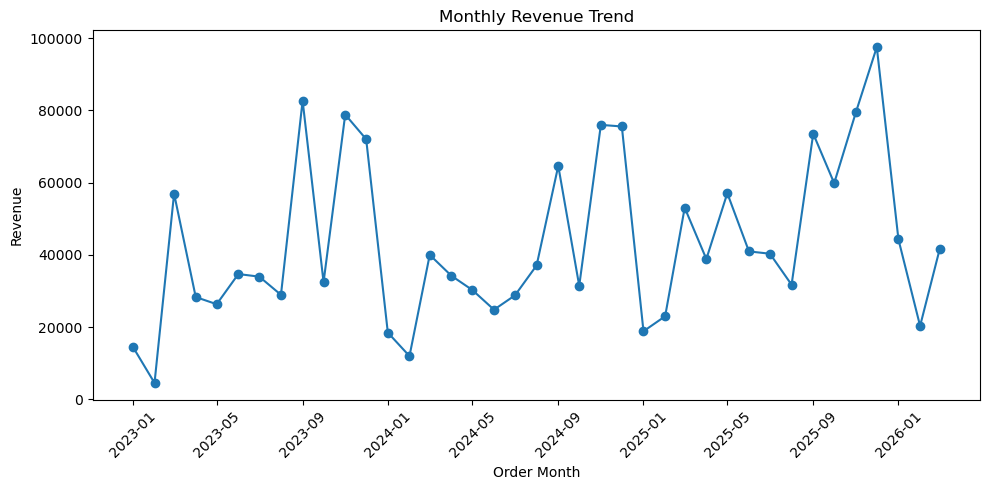

In [43]:

plt.figure(figsize=(10, 5))
plt.plot(monthly_summary["order_month"], monthly_summary["monthly_revenue"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Order Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


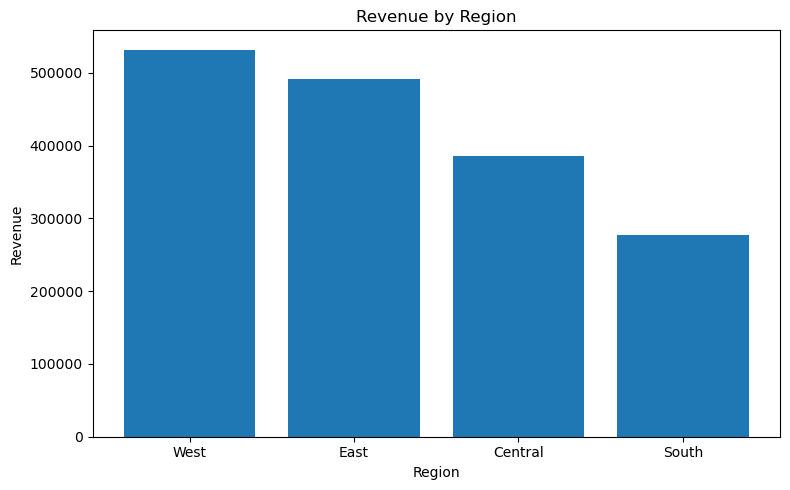

In [44]:

plt.figure(figsize=(8, 5))
plt.bar(region_summary["region"], region_summary["total_revenue"])
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


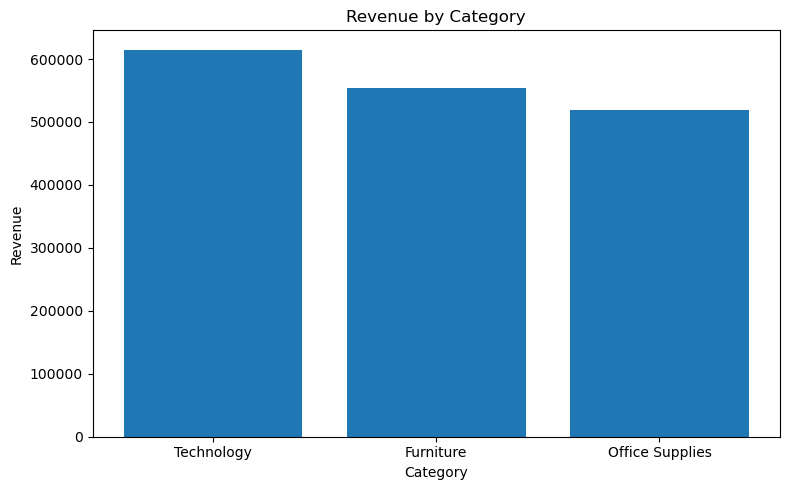

In [45]:

plt.figure(figsize=(8, 5))
plt.bar(category_summary["category"], category_summary["total_revenue"])
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


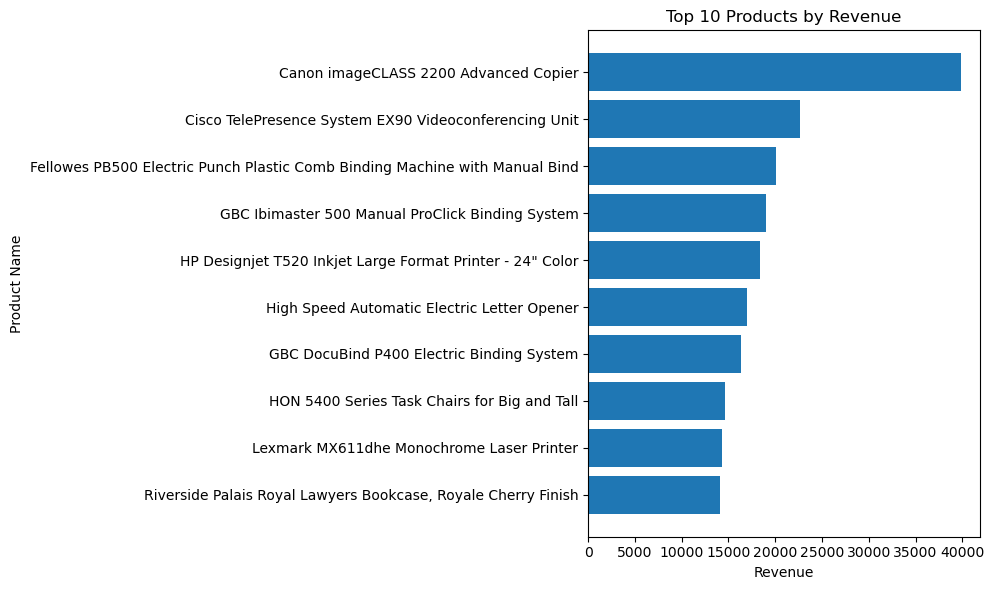

In [46]:

top_products_sorted = top_products.sort_values("total_revenue", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_products_sorted["product_name"], top_products_sorted["total_revenue"])
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()


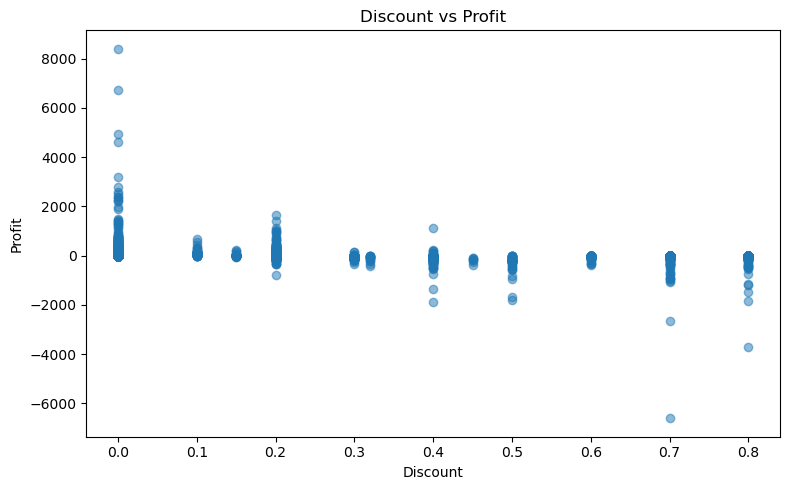

In [47]:

plt.figure(figsize=(8, 5))
plt.scatter(df["discount"], df["profit"], alpha=0.5)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


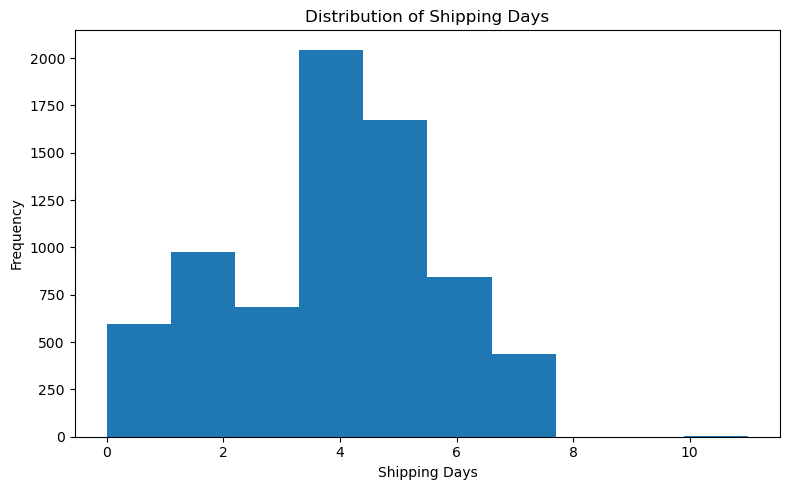

In [48]:

plt.figure(figsize=(8, 5))
plt.hist(df["ship_days"].dropna(), bins=10)
plt.title("Distribution of Shipping Days")
plt.xlabel("Shipping Days")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


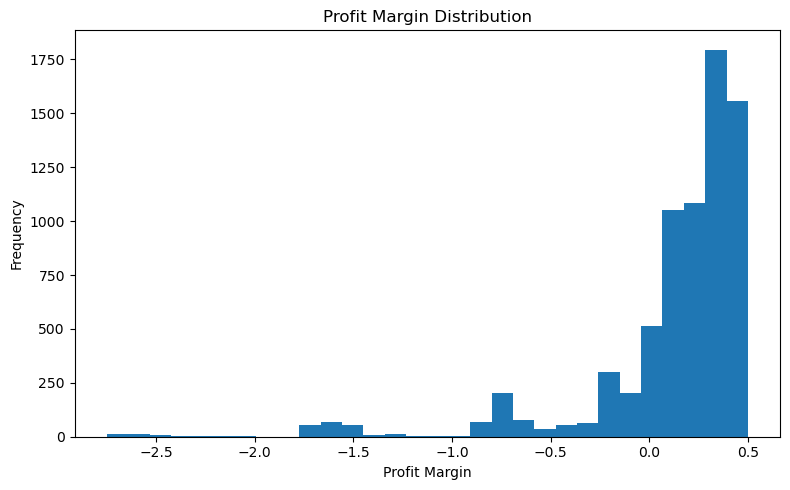

In [49]:

plt.figure(figsize=(8, 5))
plt.hist(df["profit_margin"].dropna(), bins=30)
plt.title("Profit Margin Distribution")
plt.xlabel("Profit Margin")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



## Key Insights

- The dataset generated total sales of approximately $1.69M and total profit of approximately $216K.
- Revenue performance changes over time, with some months performing much better than others.
- The West region contributes the highest total revenue, followed by the East region.
- Technology appears to be the highest-revenue category.
- A small number of products contribute a disproportionately large share of total revenue.
- High discounts are frequently associated with low or negative profit.
- The typical shipping time is around 4 days.



## Conclusion

This notebook extends the retail sales project from SQL and Tableau into Python.
It demonstrates a complete analysis workflow including data loading, quality checks, KPI calculation, trend analysis, product performance analysis, regional analysis, discount analysis, shipping analysis, and data visualisation.

This project shows practical data analyst skills used in real business analytics work.
